# Calibrate EOM voltages from measured detector responses

This notebook selects **four Alice voltages and two Bob voltages jointly** from an actual measured sweep. It does not force a sinusoidal fit or infer unmeasured voltages from a fitted phase.

**Workflow:** edit the settings below → Run All → inspect the eight measured cases and held-out checks → collect a finer/local scan or independent confirmation if needed. Nothing here controls hardware or changes GUI settings.

The old notebook derives all six voltages from `popt0`, even though both detectors are fitted. Its ideal phase spacings and minimum-voltage wrapping do not explicitly enforce detector balance. Here both detector counts enter every objective. Recorded voltage columns define the grid; no manually entered N or reconstructed linspace is used.

**What is being calibrated:** the detected fraction $p=C_{CH1}/(C_{CH1}+C_{CH2})$. A 50:50 target means equal detected rates, including background and unequal detector efficiencies. That is the requested operational target; it is not automatically equal optical power or proof of circular polarization. No background or efficiency correction is estimated from this sweep. Physical H/V/R/L labels and handedness still require optical verification.


In [4]:
from pathlib import Path
import sys, json, hashlib
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "EOM_scripts/calibration_analysis.py").exists()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook from QKD_Code or EOM_scripts.")
sys.path.insert(0, str(ROOT / "EOM_scripts"))
import calibration_analysis as cal
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 4)

FIGURES = []  # Retained for PNG/PDF export at the end.


## 1. Settings

The default CSV is an explicit example from your latest pulsed sweep; change it to the scan collected under the conditions you want to calibrate. Do not combine CW, 80 MHz and low-rate pulsed sweeps as if they were interchangeable.

The seeds below preserve the established S0/S1/S2/S3 branches. They only restrict the search to local voltage windows; they are **not fitted answers**. Increase a radius to explore farther. No requirement of equal Alice spacing or ideal Vπ is imposed.

Tolerance settings are acceptance criteria, not physical constants. A 0.05 balance tolerance means 45:55 through 55:45. The extinction tolerance limits the *wrong-detector fraction* to 15%. These can be tightened, but the notebook will report when the data cannot meet them.


In [5]:
CSV = ROOT / "data/eoms/9_28_26/BrandonsRun2/20260929_052404_374550_Detector_Traces.csv"
INDEPENDENT_CSV = None  # Optional second complete sweep; must measure the selected voltages exactly.
LEGACY_DWELL_S = None   # Only for old NI CSVs without point sidecars; approximate, exploratory only.

ALICE_SEEDS_V = [-165, -61, 43, 147]  # S0, S1, S2, S3, NOT H,V,R,L order
BOB_SEEDS_V = [30, -68]              # Existing Bob setting 1 (HV), setting 2 (RL)
ALICE_RADIUS_V = 35.
BOB_RADIUS_V = 35.
BALANCE_TOLERANCE = 0.05
EXTINCTION_TOLERANCE = 0.15
MIN_TRAINING_COUNTS_PER_PAIR = 50

TRAINING_FRACTION = 0.70
RANDOM_SEED = 20260929  # Keep fixed. Do not try many seeds and select a favorable check.
SIMULTANEOUS_CONFIDENCE = 0.95
EXPORT = True
OUTPUT_ROOT = ROOT / "data/eoms/calibrations"


## 2. Load and verify the measurement

For the PicoHarp sweep, `Raw_Count0/1` are **cumulative**, not counts collected at that row's voltage. Exact per-point counts and measured exposure come from `*_points.jsonl`; the loader checks them against rates, cumulative totals, completion status and device-error flags.

For legacy NI CSVs the counter differences include inter-point gaps. They must not be interpreted as exact dwell counts. If you explicitly supply an assumed dwell time, this notebook uses rate × assumed duration as an approximate exploratory substitute and **does not certify the resulting uncertainty check**.

The input file is never changed. Repeated measurements of the same voltage pair within one file are pooled by summing counts and exposure. Missing grid points are refused rather than silently filled.


In [6]:
grid = cal.load_sweep(CSV, LEGACY_DWELL_S)
print("Input:", grid.path)
print("Laser source:", grid.provenance["source"])
print("Count provenance:", grid.provenance["count_method"])
print("Grid:", len(grid.alice), "Alice ×", len(grid.bob), "Bob")
print("Median voltage spacing:", np.median(np.diff(grid.alice)), "V Alice;",
      np.median(np.diff(grid.bob)), "V Bob")
print("Total detector counts:", grid.counts.sum(axis=(0, 1)))
print("Summed measured exposure:", grid.seconds.sum(), "s")
if not grid.exact_counts:
    print("APPROXIMATE LEGACY MODE: validation and confidence claims are disabled.")
rates = grid.counts / grid.seconds[..., None]
total = grid.counts.sum(axis=2)
fraction = np.divide(grid.counts[..., 0], total,
                     out=np.full(total.shape, np.nan), where=total > 0)
display(pd.DataFrame(cal.TARGET, index=cal.STATES,
                     columns=["Bob setting 1: target CH1 fraction", "Bob setting 2: target CH1 fraction"]))


Input: C:\Users\nanometa\Documents\QKD_Code\data\eoms\9_28_26\BrandonsRun2\20260929_052404_374550_Detector_Traces.csv
Laser source: Laser CW (manual)
Count provenance: PicoHarp per-point sidecar
Grid: 30 Alice × 30 Bob
Median voltage spacing: 13.793103448275872 V Alice; 13.793103448275872 V Bob
Total detector counts: [1287700 1074604]
Summed measured exposure: 269.99999999999994 s


,Bob setting 1: target CH1 fraction,Bob setting 2: target CH1 fraction
S0,0.0,0.5
S1,0.5,0.0
S2,1.0,0.5
S3,0.5,1.0


The target table is your confirmed layout: S0 is bright on CH2 at Bob setting 1; S2 is bright on CH1 there. S1 is bright on CH2 at setting 2; S3 is bright on CH1 there. The other four Alice/Bob combinations should be balanced. Opposite pairs are S0/S2 and S1/S3.

The diagnostic plot below shows the actual response. Large changes in total rate can reflect source drift, polarization-dependent transmission or alignment. A sequential scan cannot distinguish those causes from a single sweep.


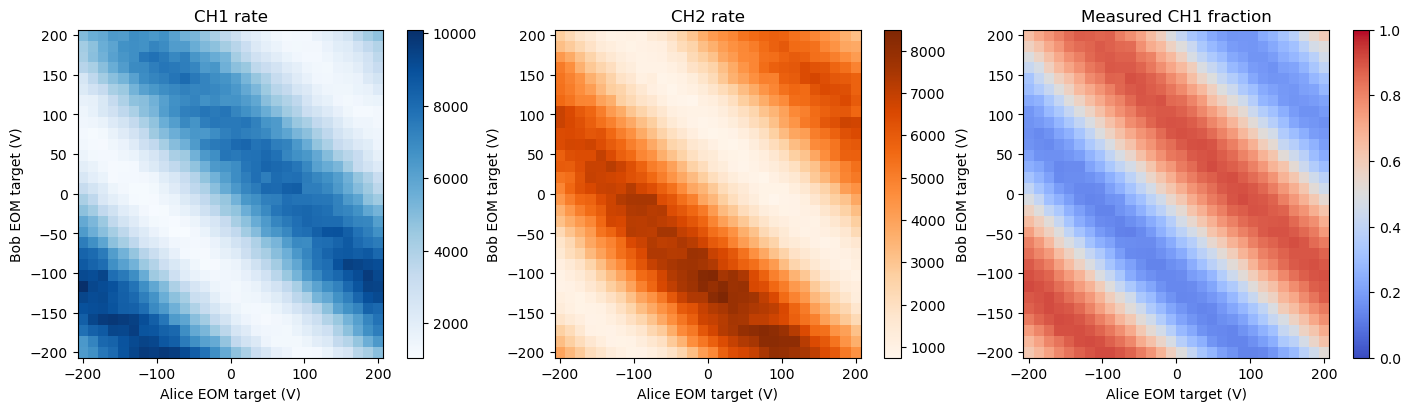

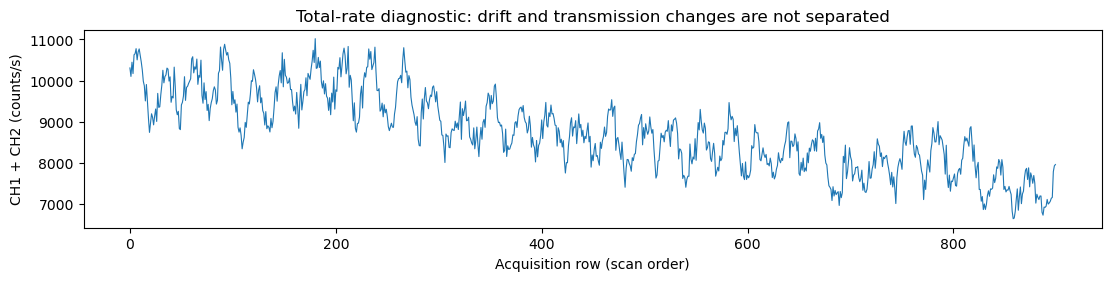

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, z, title, cmap, bounds in zip(
        axes, [rates[..., 0], rates[..., 1], fraction],
        ["CH1 rate", "CH2 rate", "Measured CH1 fraction"],
        ["Blues", "Oranges", "coolwarm"], [{}, {}, {"vmin": 0, "vmax": 1}]):
    im = ax.pcolormesh(grid.alice, grid.bob, z, shading="nearest", cmap=cmap, **bounds)
    fig.colorbar(im, ax=ax)
    ax.set(xlabel="Alice EOM target (V)", ylabel="Bob EOM target (V)", title=title)
FIGURES.append(plt.gcf())
plt.show()
fig, ax = plt.subplots(figsize=(11, 2.7), constrained_layout=True)
ax.plot(np.arange(len(grid.points)), grid.points.Rate0_Hz + grid.points.Rate1_Hz, lw=.8)
ax.set(xlabel="Acquisition row (scan order)", ylabel="CH1 + CH2 (counts/s)",
       title="Total-rate diagnostic: drift and transmission changes are not separated")
FIGURES.append(plt.gcf())
plt.show()


## 3. Select on one part of the counts; check on the remainder

Counts are randomly split **once**, 70% for selection and 30% for a check. Under an independent stationary Poisson-count model this is Poisson thinning; it is not an independent repeat acquisition and does not test drift, hysteresis, or reproducibility. Blinking/overdispersion can make count-only intervals optimistic.

For every measured Bob pair inside the windows, the algorithm assigns four **distinct measured Alice voltages**. It first prefers combinations whose training fractions meet all specified targets, if any exist. Within that class it minimizes the mean of

$$\frac{(\mu-p_{target})^2+\mathrm{Var}(p)}{\mathrm{tolerance}^2},$$

where μ and Var use the Jeffreys binomial posterior from the training counts. This discourages a lucky low-count zero from winning. Four half-split cells and four extinction cells are optimized together. If no fully feasible set exists, the best compromise is explicitly marked.

The assignment is exact for this additive loss at each Bob pair, on the measured grid and within the chosen windows. It is not a global continuous optical-model fit. Held-out counts do not rank the candidates. References: [SciPy assignment solver](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linear_sum_assignment.html), [NIST proportion intervals](https://www.itl.nist.gov/div898/handbook/prc/section2/prc241.htm).


In [8]:
train, heldout = cal.split_counts(grid, TRAINING_FRACTION, RANDOM_SEED)
candidates = cal.search(
    grid, train, ALICE_SEEDS_V, BOB_SEEDS_V,
    alice_radius=ALICE_RADIUS_V, bob_radius=BOB_RADIUS_V,
    balance_tolerance=BALANCE_TOLERANCE, extinction_tolerance=EXTINCTION_TOLERANCE,
    min_counts=MIN_TRAINING_COUNTS_PER_PAIR)
selected = candidates[0]  # Chosen only by training score; do not rerank using held-out data.
ranking = pd.DataFrame([dict(rank=i+1, training_score=c["score"],
                           training_targets_feasible=c["training_point_feasible"],
                           **dict(zip(cal.STATES, c["alice_v"])),
                           Bob1=c["bob_v"][0], Bob2=c["bob_v"][1])
                       for i, c in enumerate(candidates)])
display(ranking.head(10))
if not selected["training_point_feasible"]:
    print("NO TRAINING-FEASIBLE SET in these search windows. The first row is a compromise, not a successful calibration.")
print("Alice candidates [S0,S1,S2,S3]:", selected["alice_v"])
print("Bob candidates [setting 1, setting 2]:", selected["bob_v"])
print("Every recommended voltage pair below was actually measured; no voltage interpolation or phase wrapping.")


,rank,training_score,training_targets_feasible,S0,S1,S2,S3,Bob1,Bob2
0,1,0.5338,True,-158.6207,-62.0690,34.4828,158.6207,34.4828,-48.2759
1,2,0.6069,True,-158.6207,-48.2759,34.4828,172.4138,20.6897,-48.2759
2,3,0.6182,True,-172.4138,-89.6552,20.6897,131.0345,62.0690,-34.4828
3,4,0.4621,False,-158.6207,-75.8621,34.4828,144.8276,48.2759,-48.2759
4,5,0.5167,False,-131.0345,-48.2759,62.0690,172.4138,20.6897,-75.8621
5,6,0.5329,False,-131.0345,-48.2759,62.0690,158.6207,34.4828,-75.8621
6,7,0.5373,False,-158.6207,-89.6552,34.4828,131.0345,62.0690,-48.2759
7,8,0.5425,False,-144.8276,-48.2759,48.2759,158.6207,34.4828,-62.0690
8,9,0.5883,False,-144.8276,-75.8621,48.2759,144.8276,48.2759,-62.0690
9,10,0.5949,False,-144.8276,-48.2759,48.2759,172.4138,20.6897,-62.0690


Alice candidates [S0,S1,S2,S3]: [-158.6206896551724, -62.0689655172414, 34.48275862068965, 158.62068965517238]
Bob candidates [setting 1, setting 2]: [34.48275862068965, -48.27586206896552]
Every recommended voltage pair below was actually measured; no voltage interpolation or phase wrapping.


## 4. Inspect all eight measured cases

The full-data table describes what was recorded; it is not an independent validation because some counts were used for selection. CH1 fraction 0, 1/2, or 1 is the target, not an assumed outcome.

The **held-out** table is the selection-independent count check. Eight Wilson intervals use Bonferroni-adjusted coverage (approximately 95% simultaneous coverage under the binomial assumptions). Passing requires the **entire interval** to lie inside the allowed band. Merely containing 0.5 does not establish balance to ±0.05.


In [9]:
def evaluate(g, candidate, counts):
    return cal.evaluate(g, candidate, counts,
                        BALANCE_TOLERANCE, EXTINCTION_TOLERANCE,
                        SIMULTANEOUS_CONFIDENCE)

full_table = evaluate(grid, selected, grid.counts)
holdout_table = evaluate(grid, selected, heldout)
display(full_table[["state", "bob_setting", "alice_v", "bob_v",
                    "ch1_counts", "ch2_counts", "target_ch1",
                    "measured_ch1", "absolute_error"]])
display(holdout_table[["state", "bob_setting", "total_counts", "target_ch1",
                       "measured_ch1", "ci_low", "ci_high",
                       "point_within_tolerance", "interval_within_tolerance"]])
heldout_pass = bool(grid.exact_counts and holdout_table.interval_within_tolerance.all())
print("HELD-OUT COUNT CHECK:", "PASS" if heldout_pass else "NOT VALIDATED")
print("This does not replace a repeat acquisition or polarization-state verification.")


,state,bob_setting,alice_v,bob_v,ch1_counts,ch2_counts,target_ch1,measured_ch1,absolute_error
0,S0,1,-158.6207,34.4828,347,2064,0.0,0.1439,0.1439
1,S0,2,-158.6207,-48.2759,1265,1264,0.5,0.5002,0.0002
2,S1,1,-62.0690,34.4828,1215,1408,0.5,0.4632,0.0368
3,S1,2,-62.0690,-48.2759,316,2260,0.0,0.1227,0.1227
4,S2,1,34.4828,34.4828,2350,281,1.0,0.8932,0.1068
5,S2,2,34.4828,-48.2759,1491,1347,0.5,0.5254,0.0254
6,S3,1,158.6207,34.4828,1297,1172,0.5,0.5253,0.0253
7,S3,2,158.6207,-48.2759,2539,336,1.0,0.8831,0.1169


,state,bob_setting,total_counts,target_ch1,measured_ch1,ci_low,ci_high,point_within_tolerance,interval_within_tolerance
0,S0,1,709,0.0,0.1340,0.1028,0.1728,True,False
1,S0,2,768,0.5,0.4766,0.4277,0.5258,True,False
2,S1,1,765,0.5,0.4824,0.4334,0.5317,True,False
3,S1,2,784,0.0,0.1224,0.0940,0.1581,True,False
4,S2,1,779,1.0,0.9076,0.8752,0.9322,True,True
5,S2,2,820,0.5,0.5561,0.5084,0.6028,False,False
6,S3,1,753,0.5,0.5206,0.4708,0.5699,True,False
7,S3,2,870,1.0,0.8851,0.8522,0.9114,True,True


HELD-OUT COUNT CHECK: NOT VALIDATED
This does not replace a repeat acquisition or polarization-state verification.


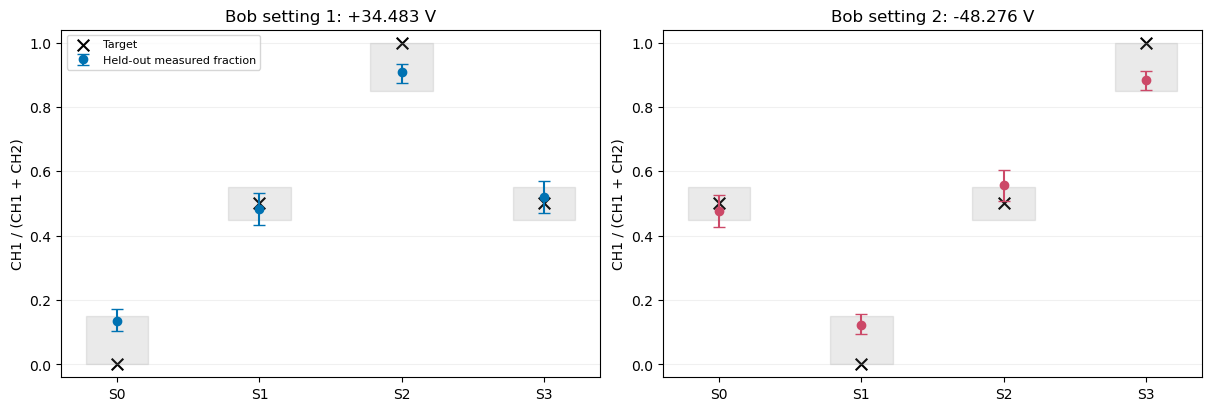

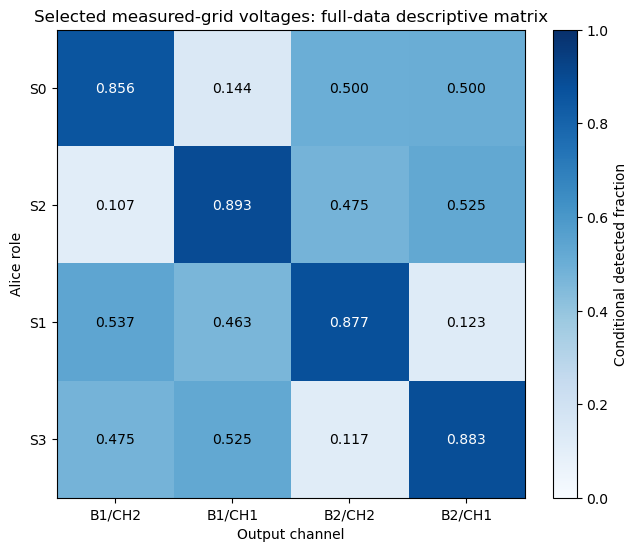

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for b, ax in enumerate(axes):
    tab = holdout_table[holdout_table.bob_setting == b+1]
    y = tab.measured_ch1.to_numpy()
    lo, hi = tab.ci_low.to_numpy(), tab.ci_high.to_numpy()
    ax.errorbar(np.arange(4), y, yerr=[y-lo, hi-y], fmt="o", capsize=4,
                color=["#0072B2", "#CC4968"][b], label="Held-out measured fraction")
    ax.scatter(np.arange(4), tab.target_ch1, marker="x", s=70, color="black", label="Target")
    for i, row in enumerate(tab.itertuples()):
        ax.fill_between([i-.22, i+.22], row.allowed_low, row.allowed_high, color="gray", alpha=.16)
    ax.set(xticks=np.arange(4), xticklabels=cal.STATES, ylim=(-.04, 1.04),
           ylabel="CH1 / (CH1 + CH2)", title=f"Bob setting {b+1}: {selected['bob_v'][b]:+.3f} V")
    ax.grid(axis="y", alpha=.18)
axes[0].legend(fontsize=8)
FIGURES.append(plt.gcf())
plt.show()

# Conditional probability matrix, with confirmed expected unity on diagonal.
q = full_table.measured_ch1.to_numpy().reshape(4, 2)
observed = np.column_stack([1-q[:, 0], q[:, 0], 1-q[:, 1], q[:, 1]])[[0, 2, 1, 3]]
fig, ax = plt.subplots(figsize=(6.8, 5.4), constrained_layout=True)
im = ax.imshow(observed, vmin=0, vmax=1, cmap="Blues")
labels = ["S0", "S2", "S1", "S3"]
ax.set(xticks=range(4), xticklabels=["B1/CH2", "B1/CH1", "B2/CH2", "B2/CH1"],
       yticks=range(4), yticklabels=labels, xlabel="Output channel", ylabel="Alice role",
       title="Selected measured-grid voltages: full-data descriptive matrix")
for (i, j), value in np.ndenumerate(observed):
    ax.text(j, i, f"{value:.3f}", ha="center", va="center",
            color="white" if value > .6 else "black")
fig.colorbar(im, ax=ax, label="Conditional detected fraction")
FIGURES.append(plt.gcf())
plt.show()


## 5. Local response and grid-resolution limits

Dots below are measured full-data fractions at each selected Bob voltage; joining lines are guides only. They make imperfect half-splits and non-sinusoidal behavior visible. The selected Alice positions are marked.

At 45 samples across ±200 V, spacing is about 9.09 V. A grid cannot prove that an unsampled 50:50 crossing is at a particular intermediate voltage. A larger number of decimal places in the printed voltage only identifies the exact grid point; it is not a voltage-accuracy claim.


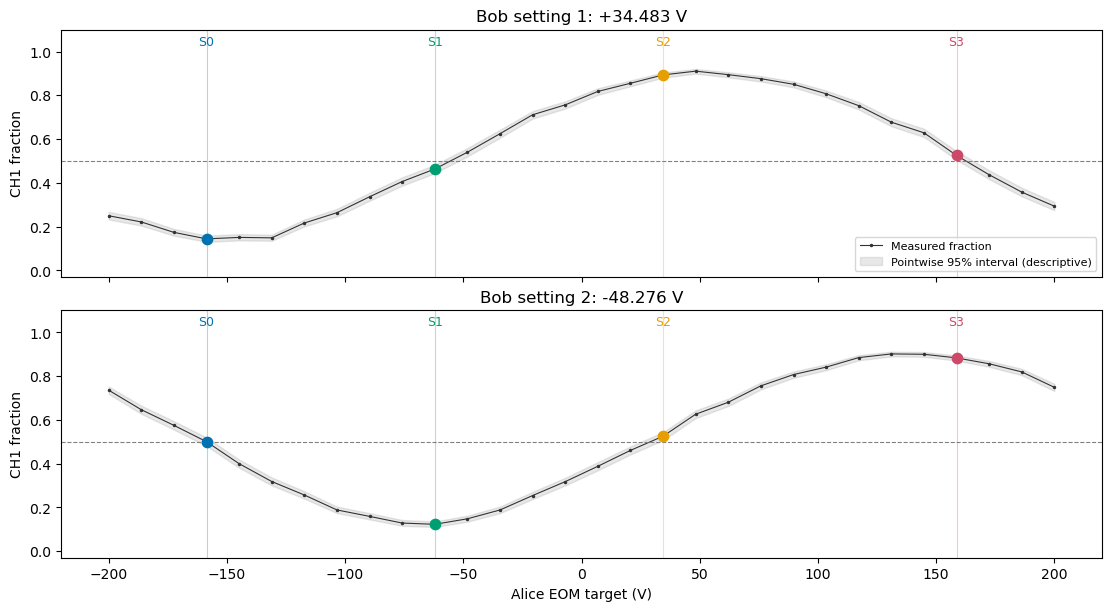

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, constrained_layout=True)
state_colors = ["#0072B2", "#009E73", "#E69F00", "#CC4968"]
for b, ax in enumerate(axes):
    bi = selected["bob_indices"][b]
    p, lo, hi = cal.wilson(grid.counts[bi, :, 0], grid.counts[bi, :, 1])
    ax.plot(grid.alice, p, ".-", color="#333333", lw=.8, ms=3, label="Measured fraction")
    ax.fill_between(grid.alice, lo, hi, color="gray", alpha=.18, label="Pointwise 95% interval (descriptive)")
    ax.axhline(.5, color="gray", ls="--", lw=.8)
    for s, ai in enumerate(selected["alice_indices"]):
        ax.scatter(grid.alice[ai], p[ai], color=state_colors[s], s=55, zorder=4)
        ax.axvline(grid.alice[ai], color=state_colors[s], alpha=.3, lw=.8)
        ax.text(grid.alice[ai], 1.03, cal.STATES[s], color=state_colors[s], ha="center", fontsize=9)
    ax.set(ylim=(-.03, 1.1), ylabel="CH1 fraction",
           title=f"Bob setting {b+1}: {grid.bob[bi]:+.3f} V")
axes[-1].set_xlabel("Alice EOM target (V)")
axes[0].legend(fontsize=8, loc="lower right")
FIGURES.append(plt.gcf())
plt.show()


## 6. Optional independent measurement

If `INDEPENDENT_CSV` is provided, evaluate the already-selected candidate without refitting or changing it. All selected voltages must be measured exactly in that file. A nearest sampled point or interpolated value is not a confirmation of an unmeasured voltage.

Use the same laser mode, power, filters, optical path, detector configuration and counting/gating convention. The sweep counts are ungated; a subsequent gated polarization matrix is a different observable. Review configuration differences explicitly. Even a passed count check establishes only this operational detector-response calibration, not H/V/R/L handedness or BB84 security.


In [12]:
independent_table = None
independent_grid = None
independent_pass = False
if INDEPENDENT_CSV is not None:
    independent_grid = cal.load_sweep(INDEPENDENT_CSV, LEGACY_DWELL_S)
    if independent_grid.provenance["csv_sha256"] == grid.provenance["csv_sha256"]:
        raise ValueError("Independent validation cannot reuse the same CSV.")
    other_candidate = cal.match_candidate(independent_grid, selected)
    independent_table = evaluate(independent_grid, other_candidate, independent_grid.counts)
    display(independent_table)
    # Be conservative about changed source, triggers or other logged acquisition settings.
    def conditions(g):
        cfg = g.provenance["acquisition_settings"] or {}
        return {k: cfg.get(k) for k in ("source", "clock", "ph330")}
    conditions_match = conditions(grid) == conditions(independent_grid)
    independent_pass = bool(grid.exact_counts and independent_grid.exact_counts
                            and conditions_match and independent_table.interval_within_tolerance.all())
    print("Logged source/trigger conditions match:", conditions_match)
    print("INDEPENDENT COUNT CHECK:", "PASS" if independent_pass else "NOT VALIDATED")
    print("Optical power, alignment and sample stability must also match; they are not inferred from the CSV.")
else:
    print("No independent measurement provided. Candidate voltages remain pending bench confirmation.")


No independent measurement provided. Candidate voltages remain pending bench confirmation.


## 7. Export candidates, diagnostics, and a finer-scan plan

The exported **candidate** JSON preserves the source hash, objective, tolerances, targets, measured voltages and validation status. It does not overwrite the GUI profile or claim that the nominal state names have been physically verified.

The refinement CSV suggests one-dimensional cuts through each selected voltage pair at quarter-grid spacing. **Those proposed points are unmeasured.** It is a planning table, not an executable acquisition script. Jointly re-evaluate the six voltages after measuring a denser local two-dimensional region, or verify all eight operating pairs repeatedly. Tuning one 50:50 case alone can spoil another because the same Alice and Bob voltages are shared.

If the count check fails only because its intervals are broad, longer dwell times may help. If the measured fraction lies outside tolerance consistently, more integration alone will not correct it. For a 50:50 proportion, about 400 photons gives a pointwise 95% uncertainty of roughly ±0.05; simultaneous eight-case acceptance and hold-out splitting require more, and acceptance requires margin inside the tolerance.


In [13]:
plan = cal.refinement_plan(grid, selected)
display(plan.head(12))
if EXPORT:
    out = OUTPUT_ROOT / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
    out.mkdir(parents=True, exist_ok=False)
    parameters = dict(alice_seeds_v=ALICE_SEEDS_V, bob_seeds_v=BOB_SEEDS_V,
                      alice_radius_v=ALICE_RADIUS_V, bob_radius_v=BOB_RADIUS_V,
                      balance_tolerance=BALANCE_TOLERANCE, extinction_tolerance=EXTINCTION_TOLERANCE,
                      minimum_training_counts=MIN_TRAINING_COUNTS_PER_PAIR,
                      training_fraction=TRAINING_FRACTION, random_seed=RANDOM_SEED,
                      simultaneous_confidence=SIMULTANEOUS_CONFIDENCE)
    report = dict(schema="qkd-measured-grid-calibration-v1",
                  status="candidate_pending_optical_confirmation",
                  source=grid.provenance, parameters=parameters, selected=selected,
                  target_ch1=cal.TARGET.tolist(), roles=list(cal.STATES),
                  heldout_count_check_passed=heldout_pass,
                  independent_count_check_passed=independent_pass,
                  independent_source=independent_grid.provenance if independent_grid else None,
                  physical_state_labels_confirmed=False,
                  objective="Training-only Jeffreys expected squared fraction error / tolerance squared; feasible sets preferred",
                  calibration_target="Detected fractions; no background/efficiency correction",
                  helper_sha256=hashlib.sha256((ROOT/"EOM_scripts/calibration_analysis.py").read_bytes()).hexdigest())
    (out/"candidate_voltages.json").write_text(json.dumps(report, indent=2, allow_nan=False), encoding="utf-8")
    ranking.to_csv(out/"training_candidates.csv", index=False)
    full_table.to_csv(out/"selected_measured_points.csv", index=False)
    holdout_table.to_csv(out/"heldout_checks.csv", index=False)
    plan.to_csv(out/"proposed_refinement_points_UNMEASURED.csv", index=False)
    if independent_table is not None:
        independent_table.to_csv(out/"independent_checks.csv", index=False)
    for figure, name in zip(FIGURES, ["measured_surfaces", "total_rate_diagnostic", "heldout_check", "selected_matrix", "local_response"]):
        figure.savefig(out / f"{name}.png", dpi=200, bbox_inches="tight")
        figure.savefig(out / f"{name}.pdf", bbox_inches="tight")
    print("Exported:", out)
    print("No hardware settings were changed.")


,state,bob_setting,varied,alice_v,bob_v,target_ch1
0,S0,1,Alice,-172.4138,34.4828,0.0
1,S0,1,Alice,-168.9655,34.4828,0.0
2,S0,1,Alice,-165.5172,34.4828,0.0
3,S0,1,Alice,-162.0690,34.4828,0.0
4,S0,1,Alice,-158.6207,34.4828,0.0
5,S0,1,Alice,-155.1724,34.4828,0.0
6,S0,1,Alice,-151.7241,34.4828,0.0
7,S0,1,Alice,-148.2759,34.4828,0.0
8,S0,1,Alice,-144.8276,34.4828,0.0
9,S0,1,Bob,-158.6207,20.6897,0.0


Exported: c:\Users\nanometa\Documents\QKD_Code\data\eoms\calibrations\20260929T053456_874855Z
No hardware settings were changed.


### Interpreting the result

- A **candidate** is a jointly selected set of measured grid points, not a continuous-fit optimum.
- A **held-out pass** supports the specified count-fraction tolerances under the counting model; it does not test repeatability.
- An **independent count-check pass** is stronger evidence under matched acquisition conditions, but physical polarization labels still need optical verification.
- If no candidate meets all targets, report that limitation. Potential causes include coarse sampling, insufficient photons, background, detector/path imbalance, drift, or an optical response that cannot satisfy every desired condition with these six static settings.

Dependencies: NumPy, pandas, SciPy, Matplotlib and IPython/Jupyter in the existing `niDaqENV`. The companion `calibration_analysis.py` contains the loader/search functions and is required alongside this notebook.
